In [32]:
import functools
from pathlib import Path
import itertools
import math
from typing import Sequence
from dataclasses import dataclass
from tqdm import tqdm
import warnings
import pickle
warnings.filterwarnings("ignore")

import scanpy as sc
from anndata import AnnData
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import non_negative_factorization
import matplotlib.pyplot as plt
import scipy
from scipy.stats import pearsonr
import seaborn as sns

In [33]:
def tuple_to_dataclass(func, dataclass_type):
    """Wraps a function that returns a tuple and converts it to a dataclass instance."""
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        return dataclass_type(*func(*args, **kwargs))
    return wrapper

In [455]:
@dataclass
class NMF_Result:
    W: np.ndarray
    H: np.ndarray
    n_iter: int | None

non_negative_factorization_wrapped = tuple_to_dataclass(non_negative_factorization, NMF_Result)
filter_by_obs_value = lambda adata, obs_column, obs_value: adata[adata.obs[obs_column] == obs_value].copy()

In [678]:
def nmf_predictor(
    adata_query: sc.AnnData, 
    adata_reference: sc.AnnData, 
    n_components: int | float,
    base_genes: Sequence[str] | pd.Index,
    predicted_genes: Sequence[str] | pd.Index,
) -> tuple:
    """
    Performs NMF to infer gene expression in `adata_query` 
    based on `adata_reference`.

    Parameters:
    -----------
    adata_query : sc.AnnData
        The single-cell/spatial query dataset where gene expression is predicted.
    adata_reference : sc.AnnData
        The single-cell reference dataset used to train the NMF model.
    n_components : int | float
        The number of components (latent factors) used in NMF.
    base_genes : Sequence[str] | pd.Index
        The genes used to train the NMF model.
    predicted_genes : Sequence[str] | pd.Index
        The genes whose expression is to be inferred.

    Returns:
    --------
    tuple:
        - original_gene_counts (np.ndarray): The actual gene expression values from `adata_query` 
          for `predicted_genes`.
        - predicted_gene_counts (np.ndarray): The inferred gene expression values using NMF.
    """
    (base_genes_query, predicted_genes_query), (base_genes_reference, predicted_genes_reference) = tuple(map(
        lambda adata: tuple(map(
            lambda genes: adata.var_names.get_indexer_for(genes), 
            (base_genes, predicted_genes))), (adata_query, adata_reference)))

    nmf_result_init = non_negative_factorization_wrapped(
        adata_reference[:, np.hstack([base_genes_reference, predicted_genes_reference])].X.toarray(), 
        n_components=n_components
    )
    nmf_result_final = non_negative_factorization_wrapped(
        adata_query[:, base_genes_query].X, 
        H=nmf_result_init.H[:, :len(base_genes)], 
        init="custom", 
        update_H=False
    )
    original_gene_counts = adata_query[:, predicted_genes].X.toarray()
    predicted_gene_counts = nmf_result_final.W @ nmf_result_init.H[:, -len(predicted_genes):]
    return original_gene_counts, predicted_gene_counts


def mean_pearsonr_nmf_predictor(
    adata_query: sc.AnnData, 
    adata_reference: sc.AnnData, 
    n_components: int | float,
    base_genes: Sequence[str] | pd.Index,
    predicted_genes: Sequence[str] | pd.Index,
) -> float:
    """
    Computes the Pearson correlation between the actual and predicted gene expression levels 
    using NMF.

    Parameters:
    -----------
    adata_query : sc.AnnData
        The single-cell query dataset where gene expression is predicted.
    adata_reference : sc.AnnData
        The single-cell reference dataset used to train the NMF model.
    n_components : int | float
        The number of components (latent factors) used in NMF.
    base_genes : Sequence[str] | pd.Index
        The genes used to train the NMF model.
    predicted_genes : Sequence[str] | pd.Index
        The genes whose expression is to be inferred.

    Returns:
    --------
    float:
        The Pearson correlation coefficient between the mean expression levels of the 
        original and predicted gene counts.
    """
    original_gene_counts, predicted_gene_counts = nmf_predictor(
        adata_query, adata_reference, n_components, base_genes, predicted_genes
    )
    return float(pearsonr(original_gene_counts.mean(axis=0), predicted_gene_counts.mean(axis=0))[0])


def bootstrap_reconstruction_pearsonr(
    adata_query: sc.AnnData, 
    adata_reference: sc.AnnData, 
    n_components: int | float,
    n_genes: int | float,
    shared_genes: Sequence[str] | pd.Index | np.ndarray,
    n_bootstrap_iterations: int = 100
) -> np.ndarray:
    """
    Computes bootstrapped Pearson correlations between actual and predicted gene expression levels 
    across multiple gene subsets.

    Parameters:
    -----------
    adata_query : sc.AnnData
        The single-cell query dataset where gene expression is predicted.
    adata_reference : sc.AnnData
        The single-cell reference dataset used to train the NMF model.
    n_components : int | float
        The number of components (latent factors) used in NMF.
    n_genes : int | float
        The number of genes to use for inference in each bootstrap iteration.
    shared_genes : Sequence[str] | pd.Index | np.ndarray
        The set of shared genes across datasets from which subsets are drawn.
    n_bootstrap_iterations : int, default=100
        The number of bootstrap iterations.

    Returns:
    --------
    np.ndarray:
        An array of Pearson correlation coefficients obtained from the bootstrapped gene subsets.
    """
    return np.apply_along_axis(
        lambda genes: mean_pearsonr_nmf_predictor(
            adata_query, adata_reference, n_components, genes[n_genes:], genes[:n_genes]
        ),
        axis=1,
        arr=np.apply_along_axis(np.random.permutation, axis=1, arr=np.tile(shared_genes, (n_bootstrap_iterations, 1)))
    )

In [848]:
adata_sp = sc.read(
   Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
).transpose()
adata_sp.obs = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs

# Reading single cell reference dataset
adata_sc = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")
adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]

sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)

shared_genes_mask_sc = np.isin(adata_sc.var_names, adata_sp.var_names)
shared_genes_mask_sp = np.isin(adata_sp.var_names, adata_sc.var_names)
shared_genes = adata_sc[:, shared_genes_mask_sc].var_names

adata_sp, adata_sc = tuple(map(lambda adata: filter_by_obs_value(adata, "celltype", "BZE"), (adata_sp, adata_sc)))

print(f"{len(shared_genes)=}")

celltypes = list(set.intersection(set(adata_sp.obs["celltype"]), set(adata_sc.obs["celltype"])))
print(f"{adata_sc=}\n{adata_sp=}")

len(shared_genes)=203
adata_sc=AnnData object with n_obs × n_vars = 325 × 21197
    obs: 'cluster', 'celltype'
    var: 'n_counts'
adata_sp=AnnData object with n_obs × n_vars = 1755 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts'


In [831]:
predicted_genes, base_genes = (lambda arr, n: (arr[:n], arr[n:]))(np.random.permutation(shared_genes), 40)
mean_pearsonr_nmf_predictor(adata_sp, adata_sc, 3, base_genes, predicted_genes)

0.5512896180152893

In [849]:
n_genes_range = [5, 10, 20, 50, 100, 150]
result = pd.DataFrame(np.array([bootstrap_reconstruction_pearsonr(adata_sp, adata_sc, 3, n_genes, shared_genes) for n_genes in n_genes_range]).T, columns=n_genes_range)

Text(0, 0.5, 'Pearson r')

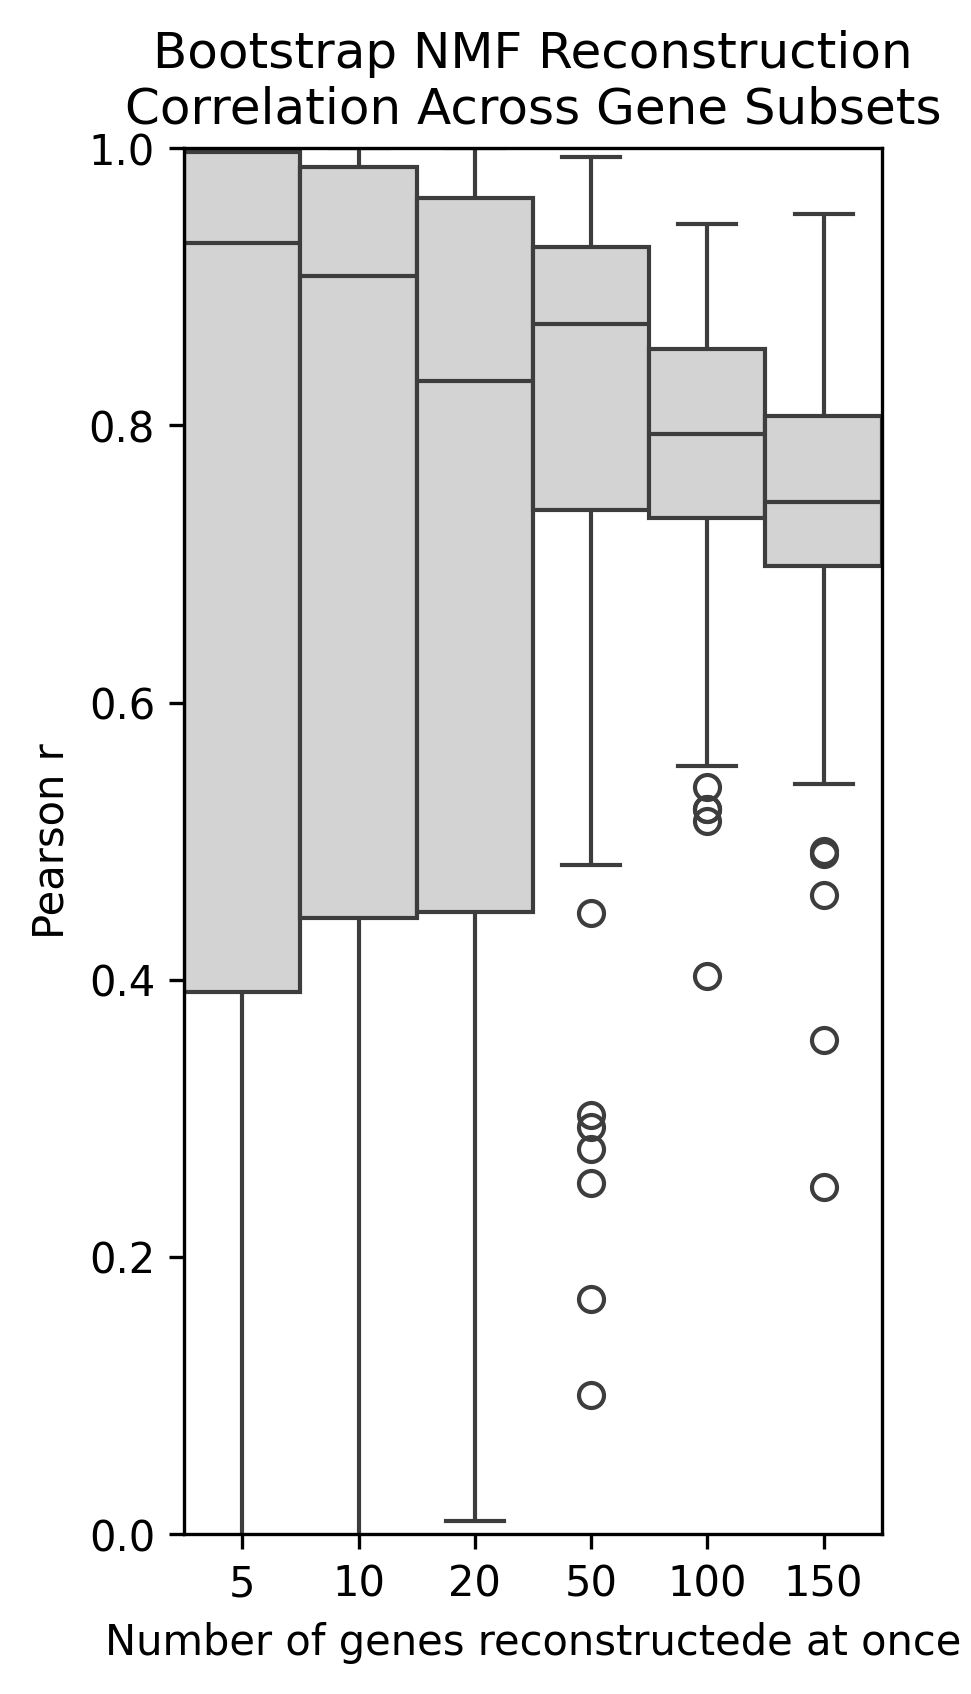

In [850]:
plt.figure(figsize=(3,6), dpi=300)
sns.boxplot(result, color="lightgrey", width=1)
plt.ylim(0, 1)
plt.title("Bootstrap NMF Reconstruction\nCorrelation Across Gene Subsets")
plt.xlabel("Number of genes reconstructede at once")
plt.ylabel("Pearson r")

{'whiskers': [<matplotlib.lines.Line2D at 0x30c801d20>,
 'caps': [<matplotlib.lines.Line2D at 0x30c802320>,
 'boxes': [<matplotlib.lines.Line2D at 0x30c801a20>],
 'medians': [<matplotlib.lines.Line2D at 0x30c802920>],
 'fliers': [<matplotlib.lines.Line2D at 0x30c802c20>],
 'means': []}

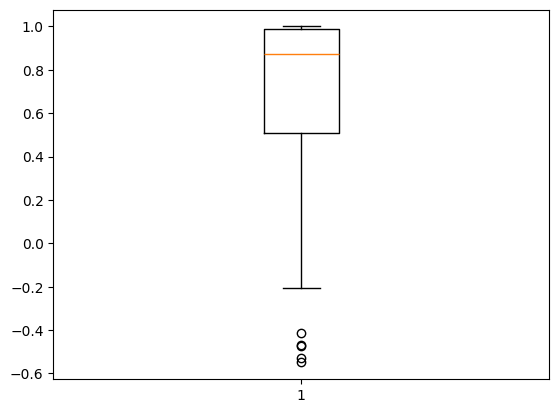

In [655]:
plt.boxplot(np.apply_along_axis(
    lambda genes: mean_pearsonr_nmf_predictor(adata_sp, adata_sc, 3, genes[5:], genes[:5]),
    axis=1,
    arr=np.apply_along_axis(np.random.permutation, axis=1, arr=np.tile(shared_genes, (100, 1)))
))

In [528]:
predicted_genes, base_genes = (lambda arr, n: (arr[:n], arr[n:]))(np.random.permutation(shared_genes), 10)
mean_pearsonr_nmf_predictor(adata_sp, adata_sc, 3, base_genes, predicted_genes)

0.9996381402015686

In [547]:
gene_iterator = [(lambda arr, n: (arr[:n], arr[n:]))(np.random.permutation(shared_genes), 10) for _ in range(10)]

In [564]:
gene_iterator = map(
    lambda _: (lambda arr, n: (arr[:n], arr[n:]))(np.random.permutation(shared_genes), 10),
    range(10)
)

results = np.array(list(map(
    lambda genes: mean_pearsonr_nmf_predictor(adata_sp, adata_sc, 3, genes[1], genes[0]),
    gene_iterator
)))
results

array([0.98332572, 0.99806398, 0.49311545, 0.89237809, 0.4282822 ,
       0.44460371, 0.99545503, 0.9932577 , 0.98435527, 0.99876052])

In [574]:
np.random.permutation(shared_genes)

array(['Fzd4', 'Cadm1', 'Etv1', 'Adrb1', 'Kiss1r', 'Cd3d', 'S1pr3',
       'Tbxa2r', 'Lpar1', 'Nlrp6', 'H2-Eb1', 'Gpr55', 'Cd44', 'Sstr3',
       'Plb1', 'Acsl1', 'Lpar5', 'Scn3a', 'Mzb1', 'Adgrd1', 'Fzd5',
       'Slc51a', 'Smo', 'Mboat4', 'Fzd2', 'Chrm3', 'Ighd', 'Cysltr1',
       'Htr4', 'Sell', 'Galr1', 'Fzd1', 'Ada', 'Apob', 'Icos', 'Fzd6',
       'Adra2a', 'Fzd9', 'Neat1', 'Lct', 'Sdc1', 'Cd14', 'Gipr', 'Mki67',
       'P2ry10', 'Cps1', 'Rcor2', 'Ptger2', 'Krt7', 'Ffar4', 'Tm4sf4',
       'Htr2b', 'Acta2', 'Cd27', 'Thy1', 'Mptx2', 'Lamp3', 'Trpm5',
       'Itgam', 'Klk1', 'Clec4a2', 'Gper1', 'Ltb4r1', 'Ffar1', 'Kit',
       'Ms4a1', 'Avil', 'Txndc5', 'Lpar6', 'Sox4', 'Scarb1', 'Cd79a',
       'Ptger4', 'Lrmp', 'Clca3b', 'Stmn1', 'C1qc', 'Hmgb2', 'Maged2',
       'Jaml', 'Chrm1', 'Ptger1', 'Nes', 'Sox10', 'Adrb2', 'Htr1b',
       'Ptprcap', 'Neurog3', 'Cd79b', 'Ifnar1', 'Vim', 'Taar4', 'Ccl9',
       'Ccnl2', 'Ffar3', 'S1pr1', 'Nt5e', 'Ptgdr', 'Cd4', 'Tnfrsf21',
       'C1qb', 'Ff

In [567]:
gene_iterator = map(
    lambda _: (lambda arr, n: (arr[:n], arr[n:]))(np.random.permutation(shared_genes), 10),
    range(10)
)
list(gene_iterator)

[(array(['Stmn1', 'Cmc1', 'Slc5a1', 'Cd14', 'Maged2', 'Cd4', 'Etv1',
         'Ccnl2', 'Adgrf5', 'Hmgb2'], dtype=object),
  array(['Ptger4', 'Fcgr4', 'Tnfrsf21', 'Slc12a2', 'Cadm1', 'Kiss1r',
         'Trpm5', 'Cysltr1', 'H2-Eb1', 'Gipr', 'Cd79a', 'Isl1', 'Ptprcap',
         'Chrm1', 'Sdc1', 'Pax6', 'Mboat4', 'Ffar2', 'Ptgdr2', 'Scarb1',
         'Marcksl1', 'S1pr1', 'Lpar1', 'Agr3', 'S1pr3', 'C1qc', 'Ffar1',
         'Cd27', 'Ffar4', 'Fzd9', 'Krt7', 'Adgrd1', 'Ada', 'Htr2b', 'Acsl1',
         'Fzd3', 'Lrmp', 'Adrb2', 'Lamp3', 'Il3ra', 'Klk1', 'Sstr3', 'Ighd',
         'S1pr2', 'Galr3', 'Ptger2', 'Chrm3', 'Cd3d', 'Ms4a1', 'Clca3b',
         'Ltb4r1', 'Sox10', 'Adrb1', 'Rcor2', 'Tbxa2r', 'Gpr55', 'Nlrp6',
         'Mzb1', 'Ifnar1', 'Jaml', 'Fzd8', 'Nt5e', 'Fzd7', 'Htr1b', 'Itgam',
         'Fzd4', 'Galr1', 'Ltb4r2', 'Cps1', 'Neurog3', 'Mki67', 'Crp',
         'Lpar2', 'Clec4a2', 'Rgs4', 'Taar4', 'Ccl9', 'Ptgdr', 'Lpar5',
         'Slc51a', 'Fzd6', 'Net1', 'Tm4sf4', 'Adra2a', 'S100b', 'K

In [ ]:
np.apply_along_axis(lambda)

{'whiskers': [<matplotlib.lines.Line2D at 0x169cc2fe0>,
 'caps': [<matplotlib.lines.Line2D at 0x169cc35e0>,
 'boxes': [<matplotlib.lines.Line2D at 0x169cc2ce0>],
 'medians': [<matplotlib.lines.Line2D at 0x169cc3be0>],
 'fliers': [<matplotlib.lines.Line2D at 0x169cc3ee0>],
 'means': []}

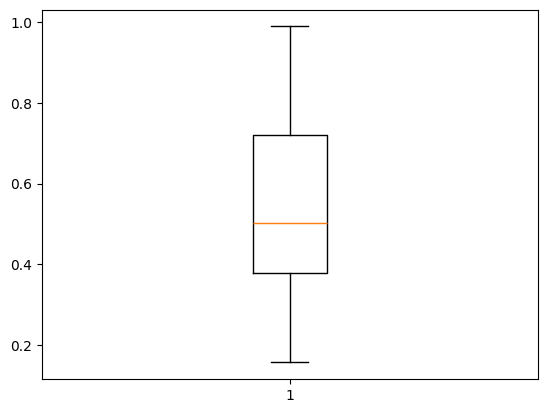

In [461]:
test = []
for _ in range(100):
    predicted_genes, base_genes = (lambda arr, n: (arr[:n], arr[n:]))(np.random.permutation(shared_genes), 50)
    test.append(mean_pearsonr_nmf_predictor(adata_sp, adata_sc, 3, base_genes, predicted_genes))
plt.boxplot(test)

{'whiskers': [<matplotlib.lines.Line2D at 0x309df8730>,
 'caps': [<matplotlib.lines.Line2D at 0x309df8c10>,
 'boxes': [<matplotlib.lines.Line2D at 0x309df8430>],
 'medians': [<matplotlib.lines.Line2D at 0x309df9210>],
 'fliers': [<matplotlib.lines.Line2D at 0x309df9510>],
 'means': []}

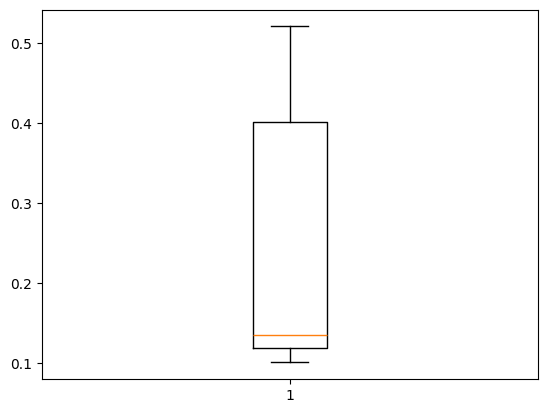

In [441]:
plt.boxplot(test)

In [373]:
list(map(functools.partial(mean_pearsonr_nmf_predictor, adata_sp, adata_sc, 3)))

TypeError: map() must have at least two arguments.

In [437]:
predicted_genes, base_genes = (lambda arr, n: (arr[:n], arr[n:]))(np.random.permutation(shared_genes), 100)
    
original_counts, predicted_counts = nmf_predictor(adata_sp, adata_sc, 3, base_genes, predicted_genes)
pearsonr(original_counts.mean(axis=0), predicted_counts.mean(axis=0))[0]

np.float32(0.13121651)

{'whiskers': [<matplotlib.lines.Line2D at 0x3143d1150>,
 'caps': [<matplotlib.lines.Line2D at 0x3143d3790>,
 'boxes': [<matplotlib.lines.Line2D at 0x30bbb38e0>],
 'medians': [<matplotlib.lines.Line2D at 0x3143d1420>],
 'fliers': [<matplotlib.lines.Line2D at 0x30bb5ff10>],
 'means': []}

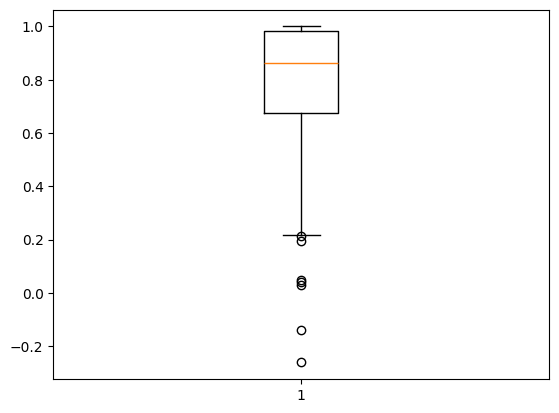

In [308]:
test = []
for _ in range(100): 
    predicted_genes, base_genes = (lambda arr, n: (arr[:n], arr[n:]))(np.random.permutation(shared_genes), 10)
    
    original_counts = adata_sp[:, predicted_genes].X.toarray().mean(axis=0)
    predicted_counts = nmf_predictor(adata_sp, adata_sc, 8, base_genes, predicted_genes).mean(axis=0)
    test.append(pearsonr(original_counts, predicted_counts)[0])

plt.boxplot(test)

<Axes: >

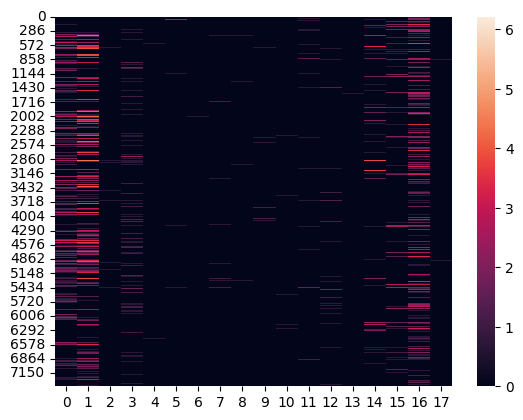

In [97]:
sns.heatmap(np.log1p(adata_sp[:, predicted_genes].X.toarray()))

In [44]:
adata_sc.X.toarray()[:, np.hstack([np.array([1,2,3]), np.array([2,3,4,5])])][:, -4:].shape

(2239, 4)

In [37]:
non_negative_factorization_wrapped(adata_sc[:, np.hstack([base_genes_reference, predicted_genes_reference])].X.toarray(), n_components=3)

NMF_Result(W=array([[8.6221142e+00, 2.8520636e-02, 0.0000000e+00],
       [1.8623766e+01, 5.5929065e-02, 6.2970124e-02],
       [5.0444485e+01, 0.0000000e+00, 6.3061401e-02],
       ...,
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00, 1.8964778e-01]], dtype=float32), H=array([[2.43298549e-04, 4.67430480e-04, 7.96187297e-03, 1.81002282e-02,
        0.00000000e+00, 9.36049502e-03, 0.00000000e+00, 0.00000000e+00,
        4.68067668e-07, 5.18159941e-03, 1.60363434e-05, 4.70871542e-04,
        0.00000000e+00, 0.00000000e+00, 2.68565986e-04, 0.00000000e+00,
        9.85834198e+01, 0.00000000e+00, 0.00000000e+00, 6.40517159e-04],
       [3.34245592e-01, 3.49964248e-03, 3.67006135e+00, 2.78302307e+01,
        3.58674937e-04, 2.59163499e-01, 1.93948892e-03, 0.00000000e+00,
        1.98446323e-05, 3.99430335e-01, 1.29559659e-04, 5.22863539e-03,
        0.00000000e+00, 1.80885196e-03, 7.08481763e-03,

In [9]:
base_genes = shared_genes[:10].copy()
predicted_genes = shared_genes[10:20].copy()

In [28]:
(base_genes_query, predicted_genes_query), (base_genes_reference, predicted_genes_reference) = tuple(map(
    lambda adata: tuple(map(
        lambda genes: adata.var_names.get_indexer_for(genes), 
        (base_genes, predicted_genes))), (adata_sp, adata_sc)))

In [27]:
base_genes_reference

array([285, 304, 326, 340, 365, 478, 482, 647, 655, 673])

In [26]:
np.hstack((base_genes_reference, predicted_genes_reference))

array([ 285,  304,  326,  340,  365,  478,  482,  647,  655,  673,  692,
        951, 1001, 1006, 1028, 1091, 1093, 1283, 1357, 1466])

In [ ]:

nmf_result_init = non_negative_factorization_wrapped(adata_sc[:, ].X, n_components=n_componens)